# Statistical Analysis

## 1. Chi-square Test

In [1]:
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats

In [3]:
# load the data
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


`Null Hypothesis:` (H₀) is a statement used in statistics that assumes there is no significant effect or relationship between two measured variables. It is the default assumption that a statistical test seeks to either reject or fail to reject.

`Alternative Hypothesis:` In statistics (including when using Python), the alternative hypothesis is a statement that contradicts the null hypothesis. It proposes that there is an effect or a difference, and it is what researchers typically try to provide evidence for

In [4]:
# creat a contigency table
contingency_table = pd.crosstab(df['sex'], df['survived'])
contingency_table

survived,0,1
sex,,
female,81,233
male,468,109


In [9]:
# perfome chi-square test
stats.chi2_contingency(contingency_table)
# print results
print('Chi-square statistic:', chi2)
print('p-value:', p)
print('Degrees of freedom:', dof)
print(f'Expected frequencies:\n {expected}')

Chi-square statistic: 260.71702016732104
p-value: 1.1973570627755645e-58
Degrees of freedom: 1
Expected frequencies:
 [[193.47474747 120.52525253]
 [355.52525253 221.47474747]]


As the p_value in this test is `p-value: 1.1973570627755645e-58` which is far less then 0.05, we reject the null hypothesis.

### 3. Normal Distribution Tast

In [11]:
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<Axes: xlabel='age', ylabel='Count'>

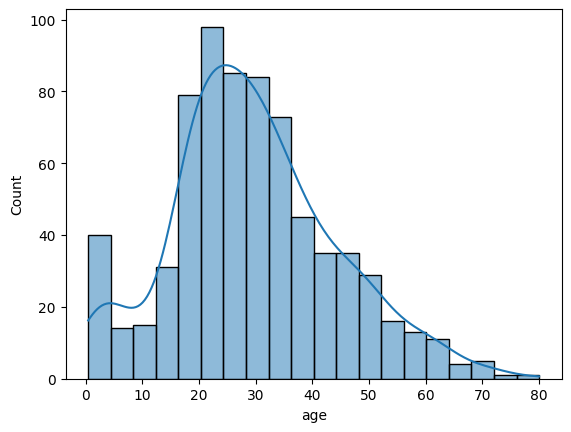

In [22]:
# grafical Meathed

sns.histplot(data=df, x='age', kde=True)

### shapiro wilk test om normal distribution Gaussian distribution
### Null Hypothesis: The data is normally distributed.
### Alternative Hypothesis: Data is note normaly distributed

In [19]:
# shapiro wilk Test

stats.shapiro(df['age'])
# shapiro wilk Test
statistic, p = stats.shapiro(df['fare'])

#print the results useing if else
if p > 0.05:
    print(f"p-value: {p}, Sample looks Gsuddion/Normaly Distribution (fail to reject h0)")
else:
    print(f"p-value: {p}, Sample does not look Gsuddion/Normaly Distribution (reject h0)")

p-value: 1.0840444395829658e-43, Sample does not look Gsuddion/Normaly Distribution (reject h0)


<Axes: xlabel='fare', ylabel='Count'>

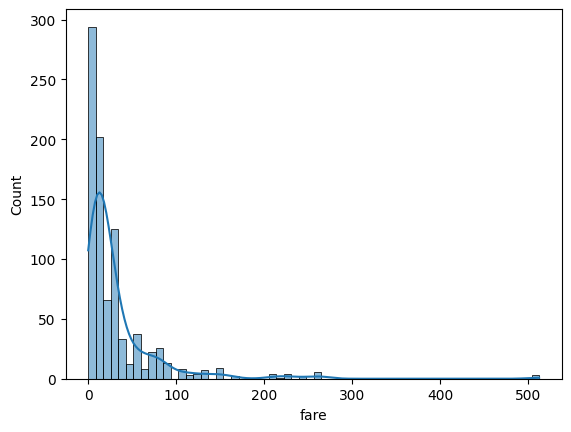

In [21]:
sns.histplot(data=df, x='fare', kde=True)

In [23]:
# shapiro wilk Test
statistic, p = stats.shapiro(df['fare'])

#print the results useing if else
if p > 0.05:
    print(f"p-value: {p}, Sample looks Gsuddion/Normaly Distribution (fail to reject h0)")
else:
    print(f"p-value: {p}, Sample does not look Gsuddion/Normaly Distribution (reject h0)")


p-value: 1.0840444395829658e-43, Sample does not look Gsuddion/Normaly Distribution (reject h0)


In [28]:
# kolmo grouss test
statistic, p_value = stats.kstest(df['fare'], 'norm')
print(f'p-value: {p_value}')
if p_value > 0.05:
    print("Sample looks Gsuddion/Normaly Distribution (fail to reject h0)") 
else:
    print("Sample does not look Gsuddion/Normaly Distribution (reject h0)")

p-value: 0.0
Sample does not look Gsuddion/Normaly Distribution (reject h0)


## t-test

In [38]:
import scipy.stats as stats

# sample data
x = [1, 2, 3, 4, 5]
# known population mean
mu = 4

# print results
print('t-statistic:', t_statistic)
print('p-value:', p)

# perform one-sample t-test
t_statistic, p_value = stats.ttest_1samp(x, mu)


# print the result using if else
if p_value > 0.05:
    print (f'p-value:{p}, sample mean is equal to papulation mean (fail to reject h0)')
else:
    print (f'p-value:{p}, sample mean is not equal to papulation mean (reject h0)')

t-statistic: -1.414213562373095
p-value: 1.0840444395829658e-43
p-value:1.0840444395829658e-43, sample mean is equal to papulation mean (fail to reject h0)


# 2. two sample t-test(indepandent)

In [45]:
import scipy.stats as stats
# sample data
group1 = [2.3, 3.4, 4.5, 2.3, 3.4]
group2 = [1.2, 2.2, 3.2, 2.2, 2.3]

# perfom indepandent two-sample t-tast
t_stat, p = stats.ttest_ind(group1, group2, equal_var=True)

print('t-statistic:', t_stat)
print('p-value:', p)

# print the result using if else
if p > 0.05:
    print (f'p-value:{p}, group1 mean is equal to group2 mean (fail to reject h0)')
else:
    print (f'p-value:{p}, group1 mean is not equal to group2 mean (reject h0)')

t-statistic: 1.8482055087756457
p-value: 0.10175647371829195
p-value:0.10175647371829195, group1 mean is equal to group2 mean (fail to reject h0)


### 3. Paird sample t-test

In [41]:
# sample data
before = [2, 3, 4, 5, 6]
after = [3, 4, 5, 6, 7]
# perform paired sample t-test
t_stat, p_val = stats.ttest_rel(before, after)

# print the results
print('t-statistic:', t_stat)
print('p-value:', p_val)

# print the result using if else
if p_val > 0.05:
    print(f'p-value: {p_val}, before mean is equal to after mean (fail to reject h0)')
else:
    print(f'p-value: {p_val}, before mean is not equal to after mean (reject h0)')

t-statistic: -inf
p-value: 0.0
p-value: 0.0, before mean is not equal to after mean (reject h0)


c:\Users\Abid\miniconda3\envs\python_eda\Lib\site-packages\scipy\stats\_axis_nan_policy.py:423: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return hypotest_fun_in(*args, **kwds)


# Test for Homogeniety

## 1. Leven's Test

In [ ]:
import scipy.stats as stats
# sample data
group1 = [2.3, 3.4, 4.5, 2.3, 3.4]
group2 = [1.2, 2.2, 3.2, 2.2, 2.3]

# perfom levene's test
w_stat, p_val = stats.levene(group1, group2)

print('w_statistic', w_stat)
print('p_value', p_val)

# print the result using if else
if p_val < 0.05:
    print(f'p-value: {p_val}, variances are equal (fail to reject h0)')
else:
    print(f'p-value: {p_val}, variances are not equal (reject h0)')

w_statistic 0.44651162790697696
p_value 0.5228039334796065
p-value: 0.5228039334796065, variances are not equal (reject h0)


## 2. Bartlett's Test

In [18]:

import scipy.stats as stats
# sample data
group1 = [2.3, 3.4, 4.5, 2.3, 3.4]
group2 = [1.2, 2.2, 3.2, 2.2, 2.3]

# perform Bartlett's test
t_stat, p_val = stats.bartlett(group1, group2)

# print the results
print("t-statistic:", t_stat)
print("p-value:", p_val)


# print the result using if else
if p_value < 0.05:
    print(f'p-value: {p_value}, variances are equal (fail to reject h0)')
else:
    print(f'p-value: {p_value}, variances are not equal (reject h0)')


t-statistic: 0.24050679805097827
p-value: 0.6238403179343277
p-value: 0.6238403179343277, variances are not equal (reject h0)


# ANOVA
Analysis of Variance

### 1. One-Way anova

In [20]:
import scipy.stats as stats

# sample data

a = [2.3, 3.4, 4.5, 2.3, 3.4]
b = [11.2, 12.2, 13.2, 12.2, 12.3]
c = [22.3, 23.4, 24.5 , 22.3, 23.4]

# perfom One-way ANOVA
f_stat, p_value = stats.f_oneway(a, b, c)

# print the results base on if else
if p_value < 0.05:
    
    print(f'p-value: {p_value},Means are equal (fail to are reject H0)')
else:
    print(f'p-value:, Means are not equal (reject H0)')


p-value: 4.279979561060641e-13,Means are equal (fail to are reject H0)
